# 제시되는 문제를 해결하시오.
**단, ######### Edit Here ######### 공간을 제외한 다른 셀이나 코드는 삭제하거나 수정해서는 안됩니다. (3번 문제 제외)**

- 모든 코드에는 **주석**을 달아 코드의 목적과 파라미터를 설명하시오.


---------------------------------
### 1. 다음 조건에 맞는 프로그램을 작성하시오. (실행 결과 만족시 총 4점:1+1+2)
- 아래와 같은 함수 및 파이썬 코드를 정의하고 각 조건을 만족하는 classify 함수를 작성하시오. ( 단, array 는 numpy 모듈의 array 임)

In [13]:
import numpy as np
from numpy import array

def readDataSet():
    group = array([[1.0, 1.1], [1.0, 1.0], [0, 0], [0, 0.1]])
    labels = ['A', 'A', 'B', 'B']
    return group, labels

def readDataSet1():
    group = array([[1.0, 1.1, 1.0], [1.0, 1.0, 1.1], [0, 0, 0.1], [0, 0.1, 0]])
    labels = ['A', 'A', 'B', 'B']
    return group, labels

testSet = array([[0.1, 0.1], [0.1, 0.2], [0.9, 0.9], [0.9, 1.0]])
testSet1 = array([[0.1, 0.1, 0.1], [0.1, 0.2, 0.1], [0.9, 0.9, 0.9], [0.9, 1.0, 1.0]])

def classify(test, dataSet, label):
  ret = None
  ############ Edit Here ##################
  test = array(test)        # 입력을 numpy array로 변환
  dataSet = array(dataSet)  # 비교 대상 데이터셋도 array로 변환

  def nearest_label(point):

      # dataSet의 각 행과 point 사이의 유클리드 거리 계산
      dist = np.sqrt(np.sum((dataSet - point) ** 2, axis=1))

      # 거리가 가장 짧은(최근접) 데이터의 인덱스를 찾아 해당 라벨 반환
      idx = np.argmin(dist)
      return label[idx]

  if test.ndim == 1:
      ret = nearest_label(test)              # test가 1차원인 경우: 라벨 1개 반환
  else:
      ret = [nearest_label(t) for t in test] # test가 2차원인 경우: 각 행마다 라벨을 구해 리스트로 반환


  #########################################
  return ret

In [14]:
dataSet, label = readDataSet()
classify(testSet[0], dataSet, label)

'B'

**결과값 ▶** B

In [15]:
dataSet, label = readDataSet1()
classify(testSet1[0], dataSet, label)

'B'

**결과값 ▶** B

In [16]:
dataSet, label = readDataSet1()
classify(testSet1, dataSet, label)

['B', 'B', 'A', 'A']

**결과값 ▶** ['B', 'B', 'A', 'A']

-------------------------------------
### 2. 다음 조건에 맞는 프로그램을 작성하시오.
기본기능 구현 : 16점
(파일 읽기 기능 : 3점, 단어 횟수 기능 : 5점, 중복 제거 기능: 5점, 정렬 기능 : 3점)
- ihaveadream.txt 파일을 입력으로 받아들인다.
- stopwords.txt 파일을 입력으로 받아들인다.
- ihaveadream.txt 파일을 공백문자를 기준으로 단어로 구분하고 구분된 단어는 영어문자로만 구성되게 전처리 한다.
- 구분된 단어들 중 stopwords.txt 의 단어들에 속하지 않는 단어들만의 등장 횟수를 계산한다
- 정리된 단어와 횟수를 쌍으로 많이 나온 단어 순으로 정렬하여 출력한다.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [58]:
sortedList = []
############ Edit Here ##################

# 1) 파일 불러오기
import os
os.getcwd()
os.chdir('/content/drive/MyDrive/Colab Notebooks/00 중간평가')
file_path = 'ihaveadream.txt'
stopwords_path = 'stopwords.txt'

# 2) stopwords 작업 (불용어 목록)
stopwords = set()                                      # 집합 형태로 넣기
with open(stopwords_path, 'r', encoding='utf-8') as f: # 파일 / 읽기/ 인코딩
    for line in f:
        tokens = line.split()                          # 공백/탭 기준으로 분리
        stopwords.update(tokens)                       # 해당 줄의 단어들 불용어 집합에 추가

# 3) ihaveadream 작업 (대상 파일)
with open(file_path, 'r', encoding='utf-8') as f:      # 파일 / 읽기/ 인코딩
    text = f.read()
words = text.split()                                   # 공백문자(띄어쓰기, 탭, 줄바꿈) 기준으로 단어 분리

# 4) 단어 전처리: 알파벳만 남기고 소문자로 통일 (정규식 없이 문자 하나하나 검사)
cleaned_words = []
for w in words:
    letters_only = ''.join(ch for ch in w if ch.isalpha())  # 알파벳인 글자만 이어붙임
    w = letters_only.lower()                                # 소문자로 변환
    if w:                                                   # 전처리 후 빈 문자열(숫자 등)은 제외
        cleaned_words.append(w)

# 5) stopwords에 속하지 않는 단어 횟수 및 중복 제거
word_counts = {}
for w in cleaned_words:
    if w in stopwords:                 # 불용어 정리한 집합을 활용
        continue                       # 불용어는 건너뜀
    if w in word_counts:
        word_counts[w] += 1            # 이미 나온 단어면 횟수 +1
    else:
        word_counts[w] = 1             # 처음 나온 단어면 1로 시작

# 6) 등장 횟수가 많은 순으로 정렬하여 (단어, 횟수) 쌍의 리스트 생성
def get_count(item):
    return item[1]
sortedList = sorted(word_counts.items(),  # 정렬 대상
                    key=get_count,        # 등장 횟수를 기준으로 정렬
                    reverse=True)         # 내림차순

#########################################
print(sortedList)


[('will', 27), ('freedom', 20), ('negro', 13), ('day', 12), ('ring', 12), ('dream', 11), ('nation', 10), ('today', 9), ('justice', 8), ('satisfied', 8), ('long', 6), ('men', 6), ('white', 6), ('years', 5), ('great', 5), ('free', 5), ('check', 5), ('america', 5), ('time', 5), ('children', 5), ('faith', 5), ('american', 4), ('hope', 4), ('land', 4), ('black', 4), ('mississippi', 4), ('mountain', 4), ('join', 3), ('stand', 3), ('injustice', 3), ('weve', 3), ('note', 3), ('rights', 3), ('people', 3), ('rise', 3), ('valley', 3), ('brotherhood', 3), ('gods', 3), ('sweltering', 3), ('alabama', 3), ('georgia', 3), ('state', 3), ('sing', 3), ('history', 2), ('slaves', 2), ('life', 2), ('segregation', 2), ('cash', 2), ('promissory', 2), ('liberty', 2), ('color', 2), ('insufficient', 2), ('funds', 2), ('refuse', 2), ('urgency', 2), ('racial', 2), ('negros', 2), ('content', 2), ('continue', 2), ('struggle', 2), ('dignity', 2), ('allow', 2), ('creative', 2), ('physical', 2), ('force', 2), ('brother

**▼ 결과값 ▼** <br>
[('will', 27), ('freedom', 20), ('negro', 13), ('day', 12), ('ring', 12), ('dream', 11), ('nation', 10), ('today', 9), ('justice', 8), ('satisfied', 8), ('long', 6), ('men', 6), ('white', 6), ('years', 5), ('great', 5), ('free', 5), ('check', 5), ('america', 5), ('time', 5), ('children', 5), ('faith', 5), ('american', 4), ('hope', 4), ('land', 4), ('black', 4), ('mississippi', 4), ('mountain', 4), ('join', 3), ('stand', 3), ('injustice', 3), ('weve', 3), ('note', 3), ('rights', 3), ('people', 3), ('rise', 3), ('valley', 3), ('brotherhood', 3), ('gods', 3), ('sweltering', 3), ('alabama', 3), ('georgia', 3), ('state', 3), ('sing', 3), ('history', 2), ('slaves', 2), ('life', 2), ('segregation', 2), ('cash', 2), ('promissory', 2), ('liberty', 2), ('color', 2), ('insufficient', 2), ('funds', 2), ('refuse', 2), ('urgency', 2), ('racial', 2), ('negros', 2), ('content', 2), ('continue', 2), ('struggle', 2), ('dignity', 2), ('allow', 2), ('creative', 2), ('physical', 2), ('force', 2), ('brothers', 2), ('realize', 2), ('destiny', 2), ('walk', 2), ('police', 2), ('brutality', 2), ('cities', 2), ('vote', 2), ('york', 2), ('mighty', 2), ('jail', 2), ('quest', 2), ('suffering', 2), ('work', 2), ('south', 2), ('knowing', 2), ('despair', 2), ('live', 2), ('true', 2), ('meaning', 2), ('sons', 2), ('heat', 2), ('boys', 2), ('girls', 2), ('hands', 2), ('hill', 2), ('places', 2), ('stone', 2), ('thee', 2), ('mountainside', 2), ('happy', 1), ('greatest', 1), ('demonstration', 1), ('score', 1), ('ago', 1), ('symbolic', 1), ('shadow', 1), ('signed', 1), ('emancipation', 1), ('proclamation', 1), ('momentous', 1), ('decree', 1), ('beacon', 1), ('light', 1), ('millions', 1), ('seared', 1), ('flames', 1), ('withering', 1), ('joyous', 1), ('daybreak', 1), ('night', 1), ('captivity', 1), ('sadly', 1), ('crippled', 1), ('manacles', 1), ('chains', 1), ('discrimination', 1), ('lives', 1), ('lonely', 1), ('island', 1), ('poverty', 1), ('midst', 1), ('vast', 1), ('ocean', 1), ('material', 1), ('prosperity', 1), ('languished', 1), ('corners', 1), ('society', 1), ('finds', 1), ('exile', 1), ('dramatize', 1), ('shameful', 1), ('condition', 1), ('sense', 1), ('nations', 1), ('capital', 1), ('architects', 1), ('republic', 1), ('wrote', 1), ('magnificent', 1), ('constitution', 1), ('declaration', 1), ('independence', 1), ('signing', 1), ('fall', 1), ('heir', 1), ('promise', 1), ('well', 1), ('guaranteed', 1), ('unalienable', 1), ('pursuit', 1), ('happiness', 1), ('obvious', 1), ('defaulted', 1), ('insofar', 1), ('citizens', 1), ('concerned', 1), ('honoring', 1), ('sacred', 1), ('obligation', 1), ('bad', 1), ('marked', 1), ('bank', 1), ('bankrupt', 1), ('vaults', 1), ('opportunity', 1), ('demand', 1), ('riches', 1), ('security', 1), ('hallowed', 1), ('spot', 1), ('remind', 1), ('fierce', 1), ('engage', 1), ('luxury', 1), ('cooling', 1), ('tranquilizing', 1), ('drug', 1), ('gradualism', 1), ('real', 1), ('promises', 1), ('democracy', 1), ('dark', 1), ('desolate', 1), ('sunlit', 1), ('path', 1), ('lift', 1), ('quicksands', 1), ('solid', 1), ('rock', 1), ('reality', 1), ('fatal', 1), ('overlook', 1), ('moment', 1), ('summer', 1), ('legitimate', 1), ('discontent', 1), ('pass', 1), ('invigorating', 1), ('autumn', 1), ('equality', 1), ('nineteen', 1), ('sixtythree', 1), ('needed', 1), ('blow', 1), ('steam', 1), ('rude', 1), ('awakening', 1), ('returns', 1), ('business', 1), ('usual', 1), ('rest', 1), ('tranquility', 1), ('granted', 1), ('citizenship', 1), ('whirlwinds', 1), ('revolt', 1), ('shake', 1), ('foundations', 1), ('bright', 1), ('emerges', 1), ('warm', 1), ('threshold', 1), ('leads', 1), ('palace', 1), ('process', 1), ('gaining', 1), ('rightful', 1), ('place', 1), ('guilty', 1), ('wrongful', 1), ('deeds', 1), ('seek', 1), ('satisfy', 1), ('thirst', 1), ('drinking', 1), ('cup', 1), ('bitterness', 1), ('hatred', 1), ('forever', 1), ('conduct', 1), ('high', 1), ('plane', 1), ('discipline', 1), ('protest', 1), ('degenerate', 1), ('violence', 1), ('majestic', 1), ('heights', 1), ('meeting', 1), ('soul', 1), ('marvelous', 1), ('militancy', 1), ('engulfed', 1), ('community', 1), ('lead', 1), ('distrust', 1), ('evidenced', 1), ('presence', 1), ('tied', 1), ('inextricably', 1), ('bound', 1), ('pledge', 1), ('march', 1), ('ahead', 1), ('turn', 1), ('devotees', 1), ('civil', 1), ('victim', 1), ('unspeakable', 1), ('horrors', 1), ('bodies', 1), ('heavy', 1), ('fatigue', 1), ('travel', 1), ('gain', 1), ('lodging', 1), ('motels', 1), ('highways', 1), ('hotels', 1), ('basic', 1), ('mobility', 1), ('smaller', 1), ('ghetto', 1), ('larger', 1), ('stripped', 1), ('selfhood', 1), ('robbed', 1), ('signs', 1), ('stating', 1), ('whites', 1), ('believes', 1), ('rolls', 1), ('waters', 1), ('righteousness', 1), ('stream', 1), ('unmindful', 1), ('trials', 1), ('tribulations', 1), ('fresh', 1), ('narrow', 1), ('cells', 1), ('areas', 1), ('left', 1), ('battered', 1), ('storms', 1), ('persecution', 1), ('staggered', 1), ('winds', 1), ('veterans', 1), ('unearned', 1), ('redemptive', 1), ('carolina', 1), ('louisiana', 1), ('slums', 1), ('ghettos', 1), ('northern', 1), ('situation', 1), ('changed', 1), ('wallow', 1), ('friends', 1), ('face', 1), ('difficulties', 1), ('tomorrow', 1), ('deeply', 1), ('rooted', 1), ('creed', 1), ('hold', 1), ('truths', 1), ('selfevident', 1), ('created', 1), ('equal', 1), ('red', 1), ('hills', 1), ('slave', 1), ('owners', 1), ('sit', 1), ('table', 1), ('oppression', 1), ('transformed', 1), ('oasis', 1), ('judged', 1), ('skin', 1), ('character', 1), ('vicious', 1), ('racists', 1), ('governor', 1), ('lips', 1), ('dripping', 1), ('interposition', 1), ('nullification', 1), ('sisters', 1), ('exalted', 1), ('low', 1), ('rough', 1), ('plain', 1), ('crooked', 1), ('straight', 1), ('glory', 1), ('lord', 1), ('revealed', 1), ('flesh', 1), ('hew', 1), ('transform', 1), ('jangling', 1), ('discords', 1), ('beautiful', 1), ('symphony', 1), ('pray', 1), ('country', 1), ('tis', 1), ('sweet', 1), ('fathers', 1), ('died', 1), ('pilgrims', 1), ('pride', 1), ('prodigious', 1), ('hilltops', 1), ('hampshire', 1), ('mountains', 1), ('heightening', 1), ('alleghenies', 1), ('pennsylvania', 1), ('snowcapped', 1), ('rockies', 1), ('colorado', 1), ('curvaceous', 1), ('slopes', 1), ('california', 1), ('lookout', 1), ('tennessee', 1), ('molehill', 1), ('village', 1), ('hamlet', 1), ('city', 1), ('speed', 1), ('jews', 1), ('gentiles', 1), ('protestants', 1), ('catholics', 1), ('spiritual', 1), ('god', 1), ('almighty', 1)]

------------------------------------
### 3. 피마 인디안 당뇨병 예측 (총 30점)
- diabetes.csv 파일을 입력으로 받아들인다. (5점)
  - Pregnancies: 임신 횟수
  - Glucose: 포도당 부하 검사 수치
  - BloodPressure: 혈압(mm Hg)
  - SkinThickness: 팔 삼두근 뒤쪽의 피하지방 측정값(mm)
  - Insulin: 혈청 인슐린(mu U/ml)
  - BMI: 체질량지수(체중(kg)/(키(m))^2)
  - DiabetesPedigreeFunction: 당뇨 내력 가중치 값
  - Age: 나이
  - Outcome: 클래스 결정 값(0또는 1)
- 각 속성(Outcome 제외)에 있는 0 값으나 null 값을 속성의 평균값으로 대체한다. (5점)
- 시각화(4개 이상) 를 하고 그래프의 의미를 기술한다. (8점)
- Outcome 을 예측하기 위한 아래 모델을 생성하여 적당한 파라미터를 찾고 accuracy 를 구한다. (12점)
  - 의사결정나무
  - SVM
  - KNN
- 아래의 셀들을 필요에 따라 생성하여 작성하시오

#### 0. 환경설정

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

#### 1. diabetes.csv 파일을 입력으로 받아들인다. (5점)

In [60]:
# 1) diabetes.csv 파일 불러오기

df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [61]:
# 2) 정보 조회

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [62]:
# 3) Null 값 조회

df.isna().sum()[df.isna().sum()>0]

,0


In [63]:
# 4) 0값 조회

(df == 0).sum()

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


##### 속성값(Feature) 별 상세 설명

| 속성명 | 설명 |
|---|---|
| **Pregnancies** (임신 횟수) | 대상자가 임신했던 총 횟수입니다. |
| **Glucose** (포도당 농도) | 경구 포도당 부하 검사 후 2시간 시점의 혈장 포도당 농도입니다. 당뇨병 진단에서 가장 핵심적인 지표 중 하나입니다. |
| **BloodPressure** (혈압) | 이완기 혈압(mmHg)을 의미합니다. 심장이 휴식기일 때 혈관이 받는 압력입니다. |
| **SkinThickness** (피부 두께) | 삼두근 피부 주름 두께(mm)입니다. 피하 지방량을 추정하여 비만도를 측정하는 지표로 쓰입니다. |
| **Insulin** (인슐린 수치) | 식후 2시간 시점의 혈청 인슐린 농도(mu U/ml)입니다. 혈당을 조절하는 호르몬의 분비 상태를 보여줍니다. |
| **BMI** (체질량 지수) | 체중(kg)을 신장(m)의 제곱으로 나눈 값(kg/m²)으로, 비만도를 평가하는 대표적인 지표입니다. |
| **DiabetesPedigreeFunction** (당뇨 내력 가중치 지수) | 가족력을 기반으로 당뇨병의 유전적 발병 확률을 점수화한 함수 값입니다. 가족 중 당뇨 환자가 많고 촌수가 가까울수록 점수가 높아집니다. |
| **Age** (나이) | 대상자의 나이(세)입니다. |
| **Outcome** (당뇨병 여부) — Target 변수 | 우리가 최종적으로 예측하거나 분류하고자 하는 결과 값입니다.<br>• 1: 당뇨병 양성 (발병)<br>• 0: 당뇨병 음성 (정상) |

#### 2. 각 속성(Outcome 제외)에 있는 0 값이나 null 값을 속성의 평균값으로 대체한다. (5점)


In [64]:
# 1) 0 값 또는 결측치(null)를 해당 속성의 평균값으로 대체

feature_cols = df.columns.drop('Outcome')     # 타겟데이터인 Outcome을 제외

for col in feature_cols:
    df[col] = df[col].replace(0, np.nan)      # 0 값을 우선 Null값으로 변환 (0과 결측치를 동일하게 처리하기 위함)
    df[col] = df[col].fillna(df[col].mean())  # Null값(원래 0이었거나 원래 결측치)을 해당 열의 평균으로 채움

df.describe()                                 # 대체 후 통계값 확인

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,4.494673,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,2.975395,30.435949,12.096346,8.790942,85.021108,6.875151,0.331329,11.760232,0.476951
min,1.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,2.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,4.494673,117.000000,72.202592,29.153420,155.548223,32.400000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,155.548223,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#### 3. 시각화(4개 이상) 를 하고 그래프의 의미를 기술한다. (8점)


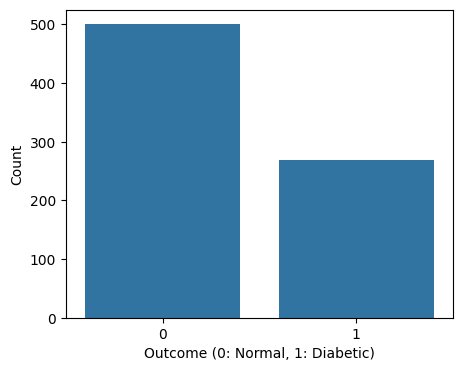

In [68]:
# 1) 당뇨/비당뇨 데이터 비율 확인
plt.figure(figsize=(5,4))
sns.countplot(x='Outcome', data=df)
plt.xlabel('Outcome (0: Normal, 1: Diabetic)')
plt.ylabel('Count')

'''
정상(0)이 당뇨(1)보다 많아 클래스가 다소 불균형함을 보여준다.
'''

plt.show()

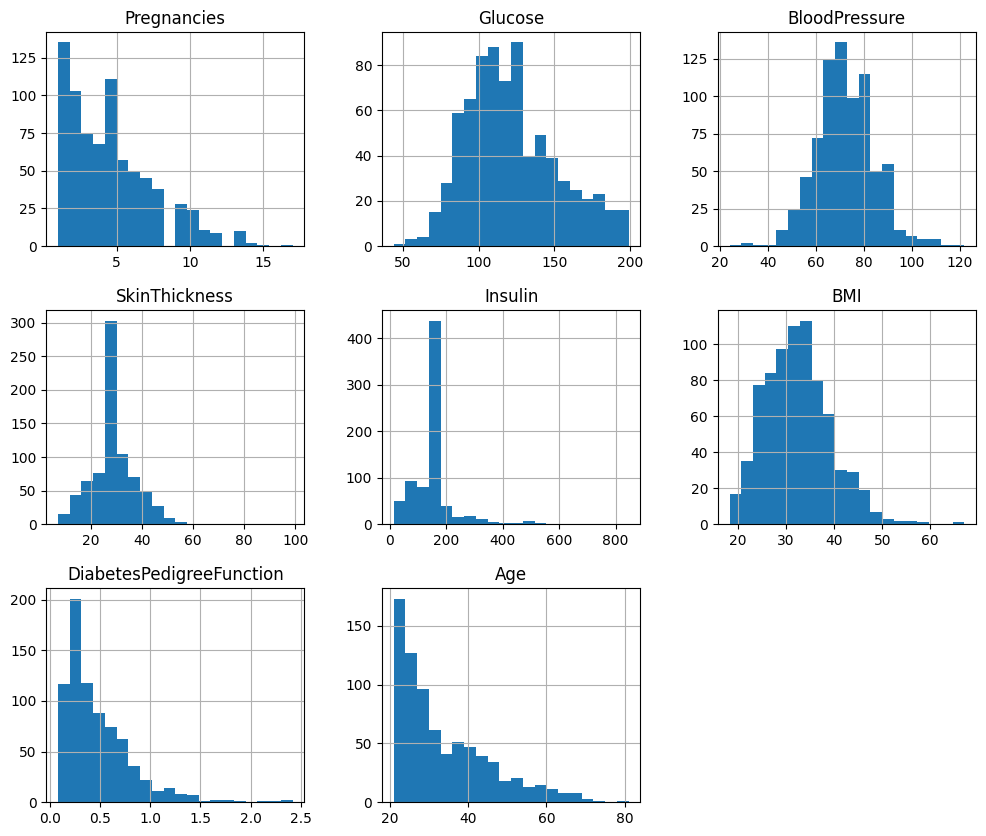

In [67]:
# 2) 히스토그램을 통한 각 변수의 분포 형태 확인

df[feature_cols].hist(figsize=(12, 10), bins=20)

'''
데이터들의 치우침 정도 확인
'''

plt.show()

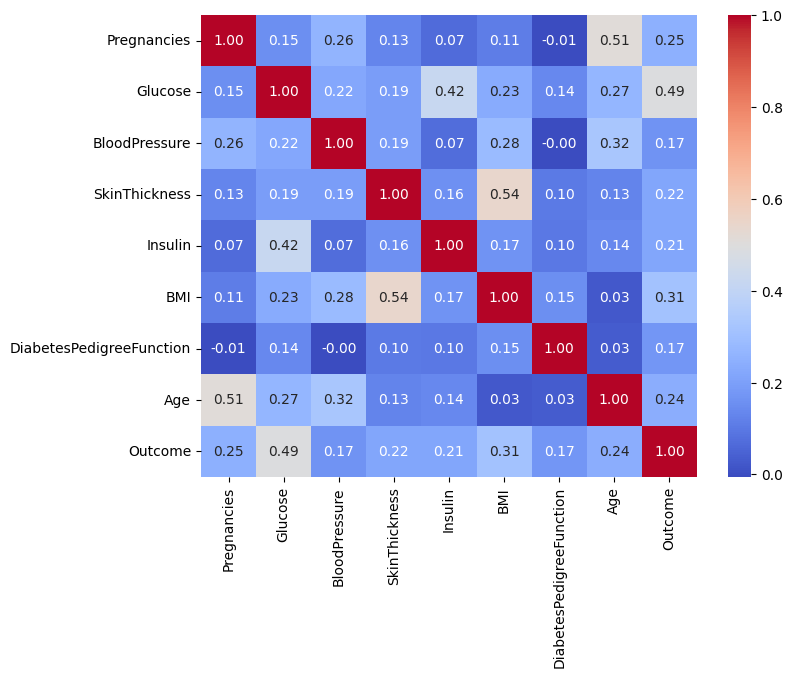

In [66]:
# 3) 히트맵을 통한 Outcome과 각 속성의 선형 관계 강도 확인

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
'''
Glucose가 Outcome과 가장 높은 상관관계를 보여 당뇨 예측에 중요한 변수임을 알 수 있다.
'''
plt.show()

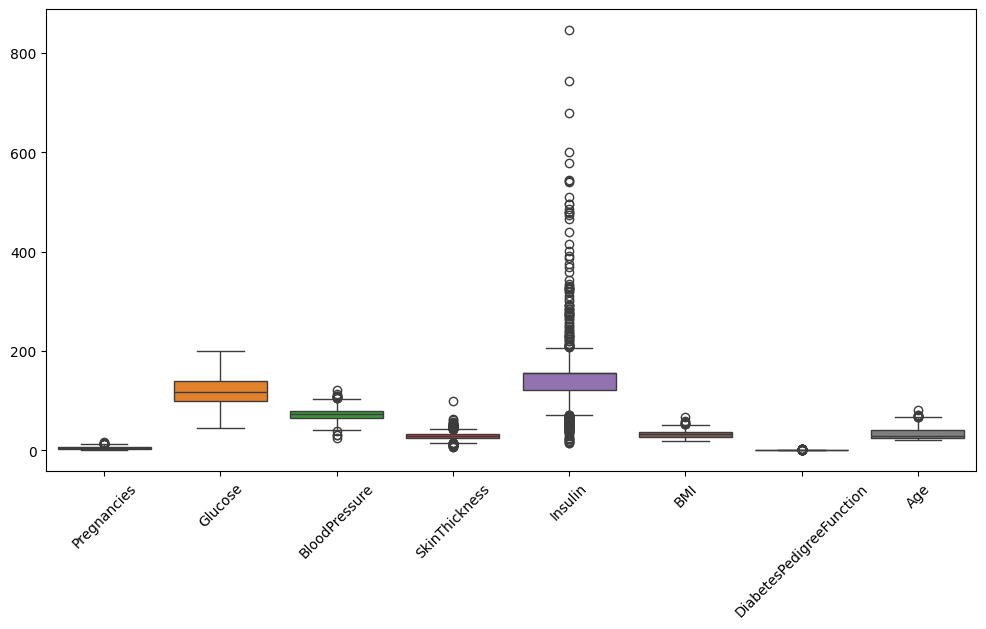

In [65]:
# 4) 박스플롯을 통한 속성별 분포와 이상치 비교
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[feature_cols])
plt.xticks(rotation=45)              # 컬럼 이름이 겹치지 않도록 x축 라벨 회전
'''
Insulin, SkinThickness 등에서 다른 속성보다 넓은 범위와 많은 이상치가 나타난다.
특히 Insulin의 수치 범위와 이상치가 꽤 많이 존재한다.
'''
plt.show()

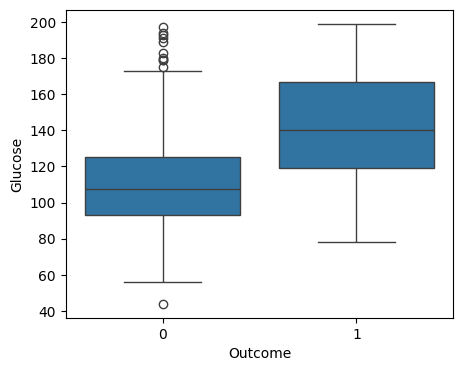

In [69]:
# 5) Glucose 박스플롯을 통한 당뇨 여부에 따른 포도당 수치 차이 확인
plt.figure(figsize=(5,4))
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.xlabel('Outcome')
plt.ylabel('Glucose')

'''
당뇨(Outcome=1) 그룹의 Glucose 중앙값과 분포가 정상 그룹보다 뚜렷하게 높다.
'''

plt.show()

#### 4. Outcome 을 예측하기 위한 아래 모델을 생성하여 적당한 파라미터를 찾고 accuracy 를 구한다. (12점)
  - 의사결정나무
  - SVM
  - KNN

In [70]:
# 1) 학습/테스트 데이터 분리 (Outcome을 타겟(y), 나머지를 특징(x)으로 사용)
x = df.drop('Outcome', axis=1)
y = df['Outcome']
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    random_state=42,
                                                    stratify=y)       # stratify: 비율(0/1)을 train/test 비율과 동일하게 유지

In [71]:
# 2) 파이프라인 기본값 지정
pipe = Pipeline([
    ('preprocess', StandardScaler()),
    ('classifier', KNeighborsClassifier())
])

In [72]:
# 3) 3개 모델(의사결정나무, SVM, KNN) 설정
param_grid = [

    # 1. Decision Tree (의사결정나무)
    {'preprocess': [None],                                     # 트리 모델은 스케일링이 필요 없어 생략
     'classifier': [DecisionTreeClassifier( random_state=42)],
     'classifier__max_depth': [3, 5, 7, 10, None],             # 트리 최대 깊이
     'classifier__min_samples_split': [2, 5, 10]},             # 노드 분할 최소 샘플 수

    # 2. SVC (RBF 커널)
    {'preprocess': [StandardScaler()],                         # 거리 기반 모델이라 스케일링 필요
     'classifier': [SVC( random_state=42)],
     'classifier__kernel': ['rbf'],
     'classifier__gamma': ['scale', 'auto', 0.1],
     'classifier__C': [0.1, 1, 10]},

    # 3. KNeighborsClassifier (KNN)
    {'preprocess': [StandardScaler()],                         # 거리 기반 모델이라 스케일링 필요
     'classifier': [KNeighborsClassifier()],
     'classifier__n_neighbors': [5, 7, 9],
     'classifier__weights': ['uniform', 'distance']}
]


In [73]:
# 4) GridSearchCV 실행 세팅
grid = GridSearchCV(pipe,
                    param_grid,
                    cv=5,
                    return_train_score=True,
                    verbose=3)

In [74]:
# 5). 학습 시작
grid.fit(x_train, y_train)

print("최고의 모델과 파라미터 조합:", grid.best_params_)
print("최고 교차 검증 점수(Accuracy):", grid.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 1/5] END classifier=DecisionTreeClassifier(random_state=42), classifier__max_depth=3, classifier__min_samples_split=2, preprocess=None;, score=(train=0.789, test=0.724) total time=   0.0s
[CV 2/5] END classifier=DecisionTreeClassifier(random_state=42), classifier__max_depth=3, classifier__min_samples_split=2, preprocess=None;, score=(train=0.764, test=0.783) total time=   0.0s
[CV 3/5] END classifier=DecisionTreeClassifier(random_state=42), classifier__max_depth=3, classifier__min_samples_split=2, preprocess=None;, score=(train=0.794, test=0.757) total time=   0.0s
[CV 4/5] END classifier=DecisionTreeClassifier(random_state=42), classifier__max_depth=3, classifier__min_samples_split=2, preprocess=None;, score=(train=0.779, test=0.730) total time=   0.0s
[CV 5/5] END classifier=DecisionTreeClassifier(random_state=42), classifier__max_depth=3, classifier__min_samples_split=2, preprocess=None;, score=(train=0.790, test=0.73

In [76]:
# 6) 테스트로 최종 accuracy 확인
test_acc = grid.score(x_test, y_test)
print("테스트 accuracy:", test_acc)

테스트 accuracy: 0.71875


#### 번외) 각 모델 별로 Accuracy 비교

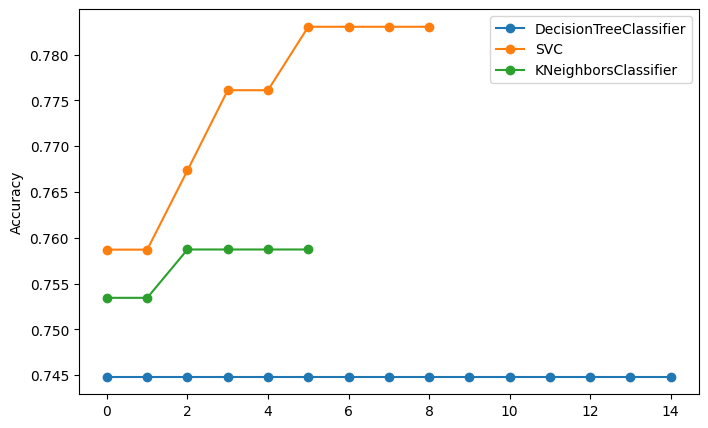

In [80]:
plt.figure(figsize=(8,5))

# 모델별로 각자의 시도 순서에서 최고 accuracy 갱신 과정을 겹쳐 그림
for model_name in results_df['model_name'].unique():
    model_results = results_df[results_df['model_name'] == model_name].reset_index(drop=True)
    model_results['best_so_far'] = model_results['mean_test_score'].cummax()                  # 모델별로 각자 누적 최댓값 계산
    plt.plot(model_results.index, model_results['best_so_far'], marker='o', label=model_name)

plt.ylabel('Accuracy')
plt.legend()            # 범례
plt.show()